# BK14_f130 混合样本波形查看器

输入一个混合后的样本文件名，自动从 `dataset_build_260505` 的日志中定位源文件，并绘制 2 行 3 列图谱：
- 第一行：时域图，断丝信号先做 5 kHz 高通滤波
- 第二行：基于 Welch 的时频图
- 第一列：断丝信号
- 第二列：噪声信号
- 第三列：混合信号

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator, FixedLocator, FuncFormatter, LogLocator, NullFormatter
from scipy import signal
from IPython.display import display

repo_root = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
src_root = repo_root / 'src'
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from bk_analysis.io import load_signal_record
from dataset_build.mixers import bandpass_for_quality

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.serif': ['Times New Roman'],
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
    'axes.unicode_minus': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
})
print('repo_root =', repo_root)

repo_root = e:\codes\ZZ-BK


## 参数

只需要修改这一格，然后重新运行后续单元。

In [7]:
# 目标混合样本文件名：可以填完整文件名，也可以只填 basename。
# selected_output_file = 'BK14-FIP-500K-20260325T150152.655-mix-F130C-0.83_1.13_-0.0015-ll.npz'
# selected_output_file = 'BK14-FIP-500K-20260326T170012.003-mix-F130A-1.42_0.85_-0.0068-x3.npz'
# selected_output_file = 'BK14-FIP-500K-20260324T144514.792-mix-F130A-0.50_0.55_0.0040-2p.npz'
selected_output_file = 'BK14-FIP-500K-20260324T191409.332-mix-F130A-0.58_1.15_0.0028-hn.npz'

# 数据集构建目录与日志。
dataset_build_root = repo_root / 'data' / 'dataset_build_260505'
dataset_build_log_csv = dataset_build_root / 'logs' / 'dataset_build_log.csv'

# 时域图高通滤波参数。
time_bandpass_low_hz = 5_000.0
time_bandpass_high_hz = 100_000.0

# Welch 时频图参数。
# outer_window_s / outer_hop_s 控制时频图的时间分辨率；
# welch_nperseg / welch_noverlap / welch_nfft 控制每个窗内的 Welch 估计。
apply_bandpass_before_welch = True
welch_pre_bandpass_low_hz = 5_000.0
welch_pre_bandpass_high_hz = 90_000.0
outer_window_s = 0.0016
outer_hop_s = 0.0002
welch_window = 'hann'
welch_nperseg = 600 # 412 Number of samples in each segment for Welch's method. Controls frequency resolution.
welch_noverlap = 550# 384
welch_nfft = 1024

# 绘图控制。
figure_size = (20, 9)
dpi = 150
height_ratios = (5, 10)
freq_range_khz = (5.0, 100.0)
power_range_db = (-110.0, -50.0)
spectrogram_cmap = 'magma'
spectrogram_y_scale = 'log'  # 'linear' or 'log'
spectrogram_time_major_tick_count = 3
spectrogram_time_minor_subdivisions = 2
spectrogram_time_xlabel = 'Time (ms)'

# 如果 F130 / F130A / F130B / F130C 的流速已知，可以在这里维护。
# 用户已确认 F130 代表 1.3 m/s；其余同系数据集先默认按 1.3 m/s 标注。
flow_speed_ms_by_dataset = {
    'F130': 1.3,
    'F130A': 1.3,
    'F130B': 1.3,
    'F130C': 1.3,
}

In [3]:
MIX_FILENAME_RE = re.compile(
    r'-mix-(?P<noise_dataset>[A-Za-z0-9]+)-(?P<w1>-?\d+\.\d+)_(?P<w2>-?\d+\.\d+)_(?P<t>-?\d+\.\d+)-'
)

def find_output_path(selected_name: str, root: Path) -> Path:
    candidate = Path(selected_name)
    if candidate.is_file():
        return candidate
    if candidate.is_absolute() and candidate.exists():
        return candidate
    direct = root / selected_name
    if direct.is_file():
        return direct
    matches = list(root.rglob(candidate.name))
    if matches:
        return matches[0]
    matches = list(root.rglob(selected_name))
    if matches:
        return matches[0]
    raise FileNotFoundError(f'Cannot locate sample: {selected_name}')

def load_log_table(log_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(log_csv)
    df['output_file_name'] = df['output_file_name'].astype(str)
    df['output_file_path'] = df['output_file_path'].astype(str)
    return df

def _normalize_mix_name(name: str) -> str:
    text = str(name).strip()
    text = text.lower()
    text = re.sub(r'-(?:200k|500k)-', '-sr-', text)
    text = re.sub(r'\.(?=npz$)', '.', text)
    return text


def find_log_row(df: pd.DataFrame, output_path: Path) -> pd.Series:
    name = output_path.name
    stem = output_path.stem
    output_name_norm = _normalize_mix_name(name)

    output_name_series = df['output_file_name'].astype(str).str.strip()
    output_path_series = df['output_file_path'].astype(str).str.strip()
    record_id_series = df['record_id'].astype(str).str.strip()

    # 1) Exact basename match.
    candidates = df[output_name_series.eq(name)]
    if candidates.empty:
        candidates = df[output_name_series.eq(stem)]
    if candidates.empty:
        candidates = df[record_id_series.eq(name)]
    if candidates.empty and stem != name:
        candidates = df[record_id_series.eq(stem)]

    # 2) If the sample-rate tag differs between disk name and log name,
    # compare after normalizing 200K/500K to a shared placeholder.
    if candidates.empty:
        norm_mask = output_name_series.map(_normalize_mix_name).eq(output_name_norm)
        candidates = df[norm_mask]

    # 3) Last fallback: timestamp + mix parameter fragment.
    if candidates.empty:
        parts = parse_mix_info(name)
        timestamp_match = re.search(r'(\d{8}T\d{6}\.\d{3})', name)
        if parts and timestamp_match:
            ts = timestamp_match.group(1)
            fragment = f"mix-{parts['noise_dataset']}-{parts['w1']:.2f}_{parts['w2']:.2f}_{parts['t']:.4f}"
            candidates = df[
                output_name_series.str.contains(ts, na=False)
                & output_name_series.str.contains(fragment, na=False)
            ]

    if candidates.empty:
        raise KeyError(f'No log row matches {name}')
    return candidates.iloc[0]

def parse_mix_info(output_name: str) -> dict:
    match = MIX_FILENAME_RE.search(output_name)
    if not match:
        return {}
    info = match.groupdict()
    info['w1'] = float(info['w1'])
    info['w2'] = float(info['w2'])
    info['t'] = float(info['t'])
    return info

def parse_starttime(value: str) -> datetime:
    return datetime.strptime(str(value), '%Y%m%dT%H%M%S.%f')

def format_clock_tick(x, _pos=None) -> str:
    dt = mdates.num2date(x)
    return dt.strftime('%H:%M:%S.%f')[:-3]


def format_ms_tick(x, _pos=None) -> str:
    return f'{x:.0f}'


def configure_time_axis(ax, time_axis: np.ndarray, major_count: int, minor_subdivisions: int) -> None:
    if len(time_axis) == 0:
        return
    time_num = mdates.date2num(time_axis)
    start = float(np.min(time_num))
    end = float(np.max(time_num))
    major_count = max(2, int(major_count))
    major_ticks = np.linspace(start, end, major_count)
    ax.xaxis.set_major_locator(FixedLocator(major_ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(format_clock_tick))
    if minor_subdivisions and major_count > 1:
        minor_total = (major_count - 1) * int(minor_subdivisions) + 1
        minor_ticks = np.linspace(start, end, minor_total)
        major_set = {round(float(t), 12) for t in major_ticks}
        minor_ticks = [float(t) for t in minor_ticks if round(float(t), 12) not in major_set]
        ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    else:
        ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.xaxis.set_minor_formatter(NullFormatter())


def configure_ms_axis(ax, duration_ms: float, major_count: int, minor_subdivisions: int) -> None:
    duration_ms = float(duration_ms)
    major_count = max(2, int(major_count))
    major_ticks = np.linspace(0.0, duration_ms, major_count)
    ax.set_xlim(0.0, duration_ms)
    ax.xaxis.set_major_locator(FixedLocator(major_ticks))
    ax.xaxis.set_major_formatter(FuncFormatter(format_ms_tick))
    if minor_subdivisions and major_count > 1:
        minor_total = (major_count - 1) * int(minor_subdivisions) + 1
        minor_ticks = np.linspace(0.0, duration_ms, minor_total)
        major_set = {round(float(t), 12) for t in major_ticks}
        minor_ticks = [float(t) for t in minor_ticks if round(float(t), 12) not in major_set]
        ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    else:
        ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.xaxis.set_minor_formatter(NullFormatter())


def configure_frequency_axis(ax, y_scale: str, freq_range_khz: tuple[float, float]) -> None:
    y_scale = str(y_scale).lower()
    ax.set_yscale(y_scale)
    if y_scale == 'log':
        major_ticks = np.array([5.0, 10.0, 20.0, 50.0, 100.0], dtype=float)
        major_ticks = major_ticks[(major_ticks >= freq_range_khz[0]) & (major_ticks <= freq_range_khz[1])]
        ax.yaxis.set_major_locator(FixedLocator(major_ticks))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_ylim(freq_range_khz[0], freq_range_khz[1] * 1.02)
    else:
        major_ticks = np.linspace(freq_range_khz[0], freq_range_khz[1], 6)
        ax.yaxis.set_major_locator(FixedLocator(major_ticks))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_formatter(NullFormatter())
        ax.set_ylim(freq_range_khz[0], freq_range_khz[1])


def load_npz_record(path: Path, method: str) -> dict:
    record = load_signal_record(path, method=method)
    with np.load(path, allow_pickle=True) as data:
        data_info = data['data_info'].item() if 'data_info' in data.files else {}
        sample_rate = float(data['sample_rate'])
        starttime = str(data['starttime'].tolist())
        arrival_time = str(data['arrival_time'].tolist())
    return {
        'record': record,
        'signal': np.asarray(record.signal, dtype=float),
        'sample_rate': sample_rate,
        'starttime': starttime,
        'arrival_time': arrival_time,
        'data_info': data_info,
    }


def build_welch_tfr(signal_values: np.ndarray, sample_rate: float, *, starttime_text: str, outer_window_s: float, outer_hop_s: float,
                    welch_window: str, welch_nperseg: int, welch_noverlap: int, welch_nfft: int,
                    use_bandpass: bool = True, bandpass_low_hz: float = 5_000.0, bandpass_high_hz: float = 100_000.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    signal_values = np.asarray(signal_values, dtype=float)
    if signal_values.size == 0:
        return np.empty((0,)), np.empty((0,)), np.empty((0, 0))

    if use_bandpass:
        signal_values = bandpass_for_quality(signal_values, sample_rate, low_cutoff_hz=bandpass_low_hz, high_cutoff_hz=bandpass_high_hz)

    frame_len = max(1, int(round(outer_window_s * sample_rate)))
    hop_len = max(1, int(round(outer_hop_s * sample_rate)))
    frame_len = min(frame_len, signal_values.size)
    if frame_len < 2:
        return np.empty((0,)), np.empty((0,)), np.empty((0, 0))

    welch_nperseg = min(welch_nperseg, frame_len)
    welch_noverlap = min(welch_noverlap, max(welch_nperseg - 1, 0))
    last_start = max(signal_values.size - frame_len, 0)
    starts = list(range(0, last_start + 1, hop_len))
    if starts[-1] != last_start:
        starts.append(last_start)
    starts = sorted(set(starts))

    start_dt = parse_starttime(starttime_text)
    times = []
    spectra = []
    freqs = None

    for start_idx in starts:
        stop_idx = min(start_idx + frame_len, signal_values.size)
        frame = signal_values[start_idx:stop_idx]
        if frame.size < 2:
            continue

        current_nperseg = min(welch_nperseg, frame.size)
        current_noverlap = min(welch_noverlap, max(current_nperseg - 1, 0))
        freqs, psd = signal.welch(
            frame,
            fs=sample_rate,
            window=welch_window,
            nperseg=current_nperseg,
            noverlap=current_noverlap,
            nfft=max(current_nperseg, welch_nfft),
            detrend='constant',
            return_onesided=True,
            scaling='density',
            average='mean',
        )
        spectra.append(psd)
        center_idx = start_idx + 0.5 * (stop_idx - start_idx)
        times.append(start_dt + timedelta(seconds=float(center_idx / sample_rate)))

    if not spectra:
        return np.empty((0,)), np.empty((0,)), np.empty((0, 0))

    psd_matrix = np.vstack(spectra)
    psd_db = 10.0 * np.log10(np.maximum(psd_matrix, 1e-20))
    return np.asarray(times, dtype=object), np.asarray(freqs, dtype=float), psd_db


def plot_sample_triptych(output_path: Path, log_row: pd.Series, *, time_bandpass_low_hz: float, time_bandpass_high_hz: float, outer_window_s: float, outer_hop_s: float,
                        welch_window: str, welch_nperseg: int, welch_noverlap: int, welch_nfft: int,
                        apply_bandpass_before_welch: bool, welch_pre_bandpass_low_hz: float, welch_pre_bandpass_high_hz: float,
                        spectrogram_y_scale: str = 'log',
                        spectrogram_time_major_tick_count: int = 6,
                        spectrogram_time_minor_subdivisions: int = 4,
                        spectrogram_time_xlabel: str = 'Time (ms)',
                        figure_size=(20, 9), dpi=150, height_ratios=(5, 10),
                        freq_range_khz=(5.0, 100.0), power_range_db=(-110.0, -40.0),
                        spectrogram_cmap='magma', flow_speed_ms_by_dataset=None):
    flow_speed_ms_by_dataset = flow_speed_ms_by_dataset or {}
    bandpass_note = f'{welch_pre_bandpass_low_hz / 1000.0:.0f}-{welch_pre_bandpass_high_hz / 1000.0:.0f} kHz band pass'

    with np.load(output_path, allow_pickle=True) as mixed_data:
        mixed_signal = np.asarray(mixed_data['phase_data'], dtype=float)
        mixed_sample_rate = float(mixed_data['sample_rate'])
        mixed_starttime = str(mixed_data['starttime'].tolist())
        mixed_info = mixed_data['data_info'].item() if 'data_info' in mixed_data.files else {}

    source_noise_path = Path(log_row['source_noise_file_path'])
    source_bk_path = Path(log_row['source_bk_file_path'])

    noise = load_npz_record(source_noise_path, method=str(log_row.get('source_noise_dataset', 'flow_noise')))
    broken = load_npz_record(source_bk_path, method=str(log_row.get('source_bk_method', 'cut')))

    mixed = {
        'signal': mixed_signal,
        'sample_rate': mixed_sample_rate,
        'starttime': mixed_starttime,
        'data_info': mixed_info,
    }

    mix_info = parse_mix_info(output_path.name)
    w1 = float(mixed_info.get('w1', mix_info.get('w1', log_row.get('w1', np.nan))))
    w2 = float(mixed_info.get('w2', mix_info.get('w2', log_row.get('w2', np.nan))))
    window_duration_s = float(mixed_info.get('window_duration_s', log_row.get('output_duration_s', 0.02)))

    source_bk_start = parse_starttime(broken['starttime'])
    window_start_dt = source_bk_start + timedelta(seconds=float(log_row['window_start_absolute_offset_s']))
    window_end_dt = window_start_dt + timedelta(seconds=window_duration_s)

    source_noise_dataset = str(log_row.get('source_noise_dataset', ''))
    noise_speed = flow_speed_ms_by_dataset.get(source_noise_dataset, None)
    if noise_speed is None:
        noise_title = f's2(t): flow noise ({source_noise_dataset}, {bandpass_note})'
    else:
        noise_title = f's2(t): flow noise ({noise_speed:.1f} m/s, {bandpass_note})'

    fig, axes = plt.subplots(
        2,
        4,
        figsize=figure_size,
        dpi=dpi,
        sharex=False,
        constrained_layout=False,
        gridspec_kw={'height_ratios': height_ratios, 'width_ratios': [1.0, 1.0, 1.0, 0.05], 'hspace': 0.05, 'wspace': 0.22},
    )
    axes[0, 3].axis('off')
    cax = axes[1, 3]

    top_specs = [
        ('s1(t): wire break (band pass)', broken),
        (noise_title, noise),
        (f's3(t) = {w1:.2f}*s1 + {w2:.2f}*s2', mixed),
    ]

    for col, (title, item) in enumerate(top_specs):
        signal_values = np.asarray(item['signal'], dtype=float)
        sample_rate = float(item['sample_rate'])
        starttime = str(item['starttime'])
        time_axis_dt = np.array([parse_starttime(starttime) + timedelta(seconds=float(i / sample_rate)) for i in range(signal_values.size)], dtype=object)
        hp_values = bandpass_for_quality(signal_values, sample_rate, low_cutoff_hz=time_bandpass_low_hz, high_cutoff_hz=time_bandpass_high_hz)

        ax = axes[0, col]
        ax.plot(time_axis_dt, hp_values, color='black', linewidth=0.9)
        ax.set_title(title)
        ax.grid(True, alpha=0.25, linewidth=0.5)
        if col == 0:
            ax.set_ylabel('Amplitude')
            ax.yaxis.set_label_coords(-0.16, 0.5)
            ax.axvspan(window_start_dt, window_end_dt, color='tab:orange', alpha=0.18, linewidth=0)
            if hp_values.size:
                ax.text(window_start_dt, float(np.nanmax(hp_values)), 'extraction window', ha='left', va='top', color='tab:orange')
        else:
            ax.set_ylabel('')
        ax.xaxis.set_major_formatter(FuncFormatter(format_clock_tick))
        ax.tick_params(axis='both', which='major', labelsize=20, length=8)
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xlim(time_axis_dt[0], time_axis_dt[-1] if len(time_axis_dt) else None)

    last_mappable = None
    for col, item in enumerate([broken, noise, mixed]):
        signal_values = np.asarray(item['signal'], dtype=float)
        sample_rate = float(item['sample_rate'])
        starttime = str(item['starttime'])
        if apply_bandpass_before_welch:
            signal_for_tfr = bandpass_for_quality(signal_values, sample_rate, low_cutoff_hz=welch_pre_bandpass_low_hz, high_cutoff_hz=welch_pre_bandpass_high_hz)
        else:
            signal_for_tfr = signal_values

        time_axis, freqs_hz, psd_db = build_welch_tfr(
            signal_for_tfr,
            sample_rate,
            starttime_text=starttime,
            outer_window_s=outer_window_s,
            outer_hop_s=outer_hop_s,
            welch_window=welch_window,
            welch_nperseg=welch_nperseg,
            welch_noverlap=welch_noverlap,
            welch_nfft=welch_nfft,
            use_bandpass=False,
            bandpass_low_hz=welch_pre_bandpass_low_hz,
            bandpass_high_hz=welch_pre_bandpass_high_hz,
        )

        ax = axes[1, col]
        if time_axis.size == 0 or freqs_hz.size == 0:
            ax.text(0.5, 0.5, 'No TFR data', transform=ax.transAxes, ha='center', va='center')
            continue

        freq_mask = (freqs_hz >= freq_range_khz[0] * 1000.0) & (freqs_hz <= freq_range_khz[1] * 1000.0)
        freqs_plot = freqs_hz[freq_mask] / 1000.0
        psd_plot = psd_db[:, freq_mask].T
        signal_start_dt = parse_starttime(starttime)
        t_ms = np.array([(t - signal_start_dt).total_seconds() * 1000.0 for t in time_axis], dtype=float)
        mesh = ax.pcolormesh(t_ms, freqs_plot, psd_plot, shading='auto', cmap=spectrogram_cmap,
                             vmin=power_range_db[0], vmax=power_range_db[1])
        last_mappable = mesh
        configure_frequency_axis(ax, spectrogram_y_scale, freq_range_khz)
        configure_ms_axis(ax, (len(signal_values) / sample_rate) * 1000.0, spectrogram_time_major_tick_count, spectrogram_time_minor_subdivisions)
        ax.tick_params(axis='both', which='major', labelsize=20, length=12)
        ax.tick_params(axis='both', which='minor', length=8)
        ax.tick_params(axis='x', which='minor', labelbottom=False)
        if col == 0:
            ax.set_ylabel('Frequency (kHz)')
            ax.yaxis.set_label_coords(-0.16, 0.5)
        else:
            ax.set_ylabel('')

    fig.supxlabel(spectrogram_time_xlabel)

    if last_mappable is not None:
        cbar = fig.colorbar(last_mappable, cax=cax)
        cbar.set_label('PSD (dB)')
        cbar.ax.tick_params(labelsize=20)
        cbar.set_ticks(np.linspace(power_range_db[0], power_range_db[1], 6))

    fig.suptitle(output_path.name, y=0.995)
    fig.subplots_adjust(left=0.07, right=0.97, bottom=0.1, top=0.92, wspace=0.22, hspace=0.05)
    return fig, axes


,output_file_name,dataset_name,source_noise_dataset,source_bk_method,w1,w2,window_start_offset_t_s,window_start_absolute_offset_s,target_sample_rate_hz
719,BK14-FIP-500K-20260324T191409.332-mix-F130A-0....,BK14_f130a_train,F130A,cut,0.58,1.15,0.0028,0.0184,500000.0


output_path = e:\codes\ZZ-BK\data\dataset_build_260505\BK14_f130a_train\BK14-FIP-500K-20260324T191409.332-mix-F130A-0.58_1.15_0.0028-hn.npz
source_noise_file_path = e:\codes\ZZ-BK\data\F130A\F130A-FIP-200K-20260324T100101.474.npz
source_bk_file_path = e:\codes\ZZ-BK\data\BK14-0.06S(Generation method)\cut\BK14-FIP-500K-20260324T191409.332.npz
parsed mix info = {'noise_dataset': 'F130A', 'w1': 0.58, 'w2': 1.15, 't': 0.0028}


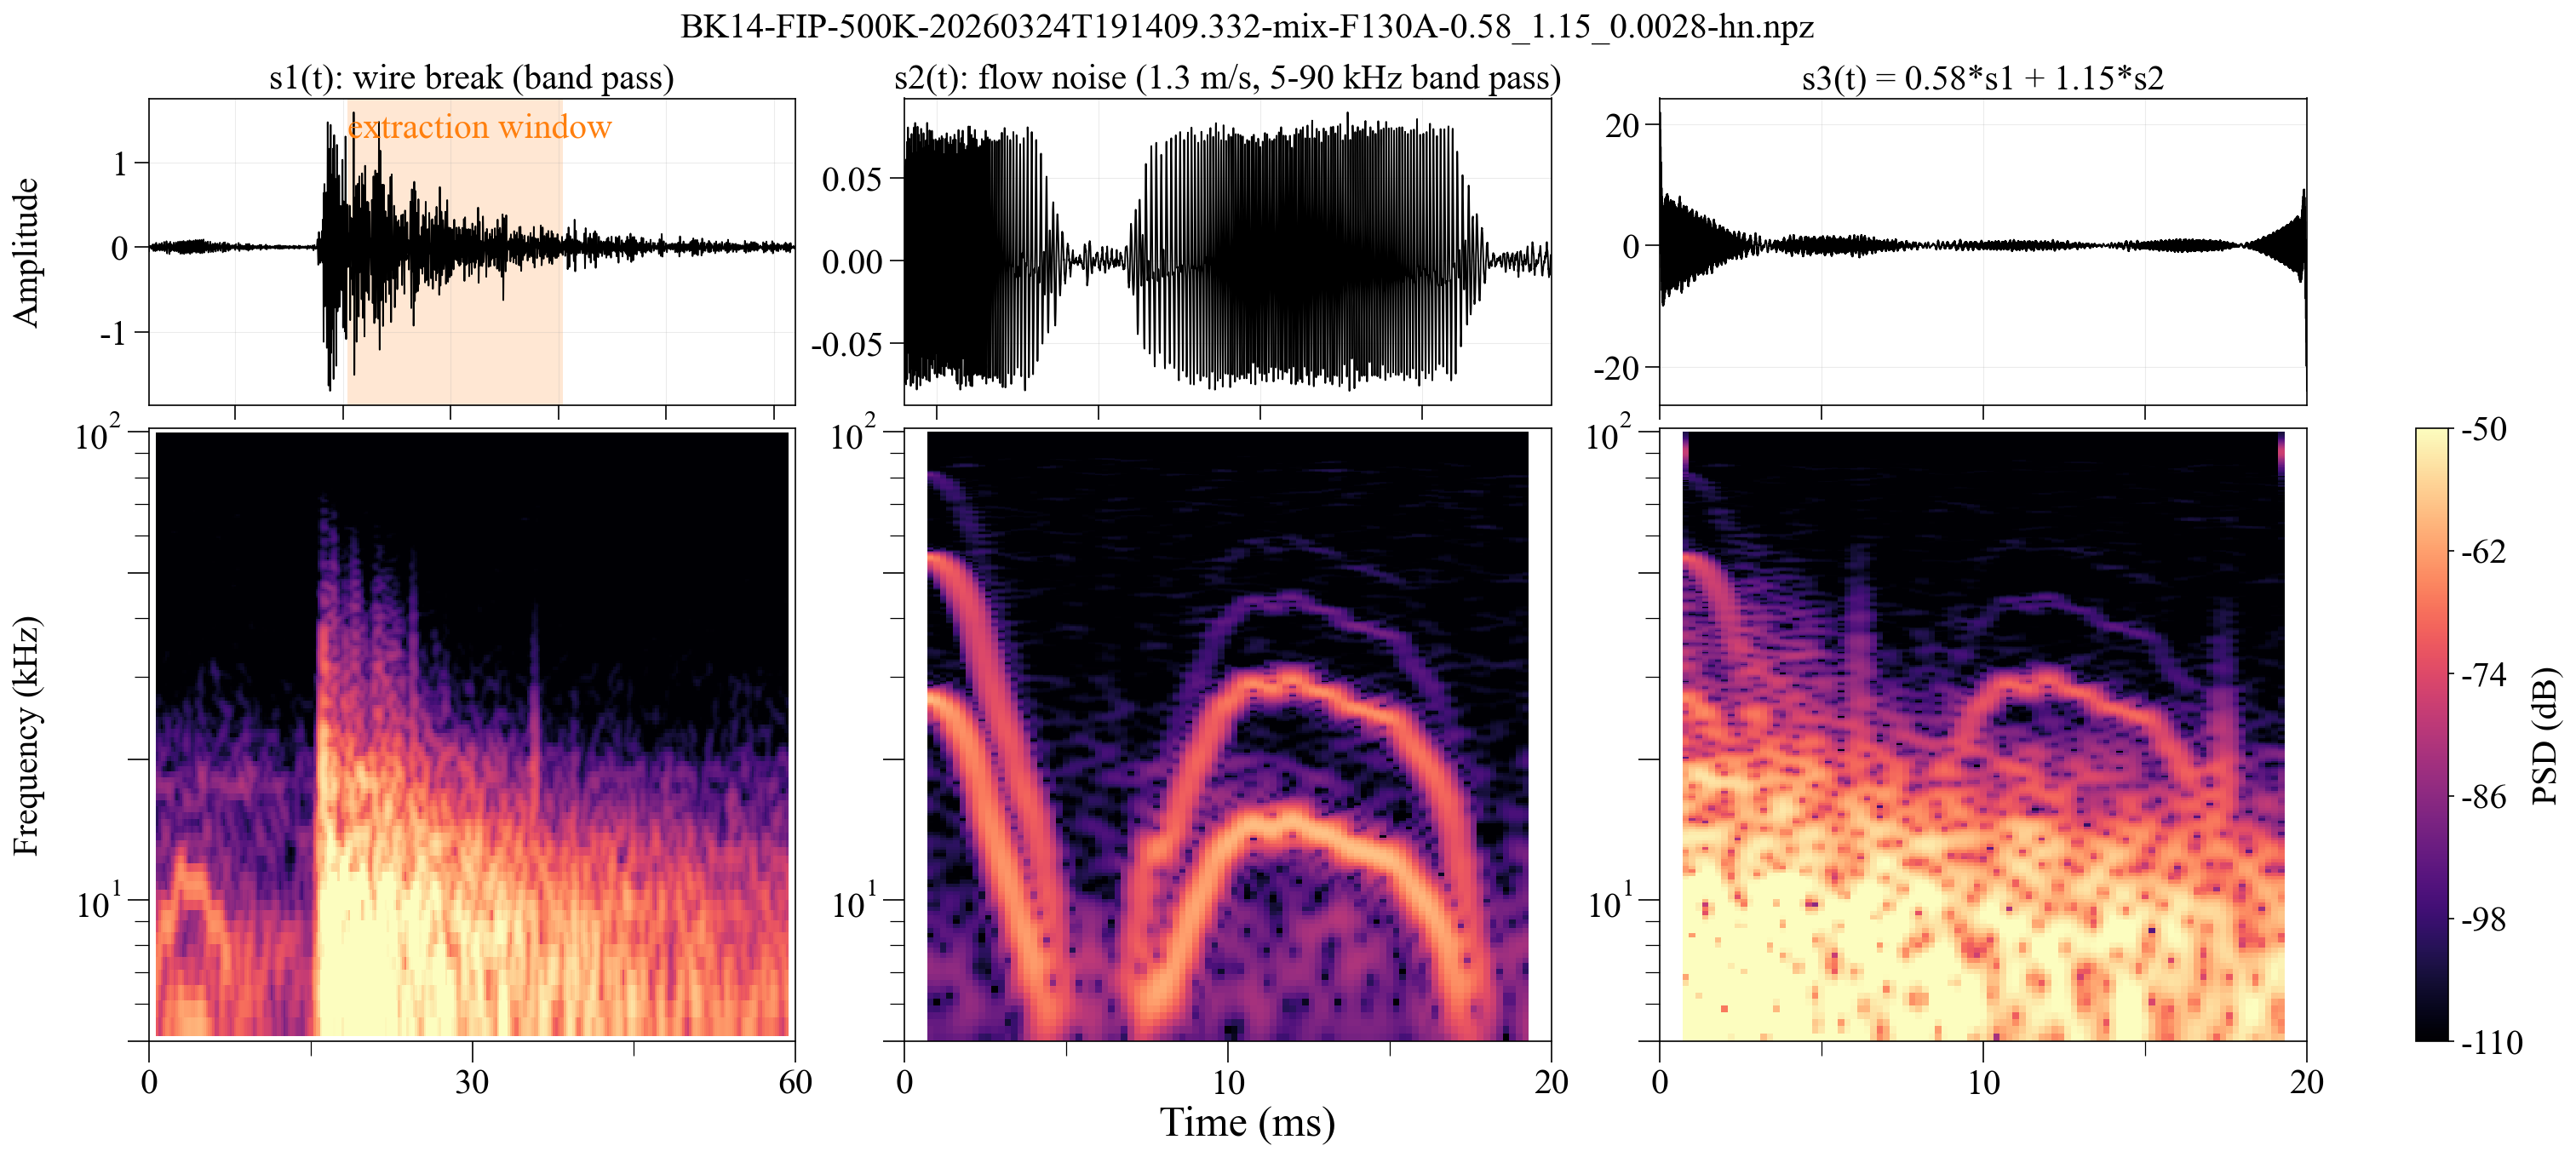

In [8]:
log_df = load_log_table(dataset_build_log_csv)
output_path = find_output_path(selected_output_file, dataset_build_root)
log_row = find_log_row(log_df, output_path)
mix_info = parse_mix_info(output_path.name)

display(pd.DataFrame([log_row])[['output_file_name', 'dataset_name', 'source_noise_dataset', 'source_bk_method', 'w1', 'w2', 'window_start_offset_t_s', 'window_start_absolute_offset_s', 'target_sample_rate_hz']])
print('output_path =', output_path)
print('source_noise_file_path =', log_row['source_noise_file_path'])
print('source_bk_file_path =', log_row['source_bk_file_path'])
print('parsed mix info =', mix_info)

fig, axes = plot_sample_triptych(
    output_path,
    log_row,
    time_bandpass_low_hz=time_bandpass_low_hz,
    time_bandpass_high_hz=time_bandpass_high_hz,
    outer_window_s=outer_window_s,
    outer_hop_s=outer_hop_s,
    welch_window=welch_window,
    welch_nperseg=welch_nperseg,
    welch_noverlap=welch_noverlap,
    welch_nfft=welch_nfft,
    apply_bandpass_before_welch=apply_bandpass_before_welch,
    welch_pre_bandpass_low_hz=welch_pre_bandpass_low_hz,
    welch_pre_bandpass_high_hz=welch_pre_bandpass_high_hz,
    spectrogram_y_scale=spectrogram_y_scale,
    spectrogram_time_major_tick_count=spectrogram_time_major_tick_count,
    spectrogram_time_minor_subdivisions=spectrogram_time_minor_subdivisions,
    spectrogram_time_xlabel=spectrogram_time_xlabel,
    figure_size=figure_size,
    dpi=dpi,
    height_ratios=height_ratios,
    freq_range_khz=freq_range_khz,
    power_range_db=power_range_db,
    spectrogram_cmap=spectrogram_cmap,
    flow_speed_ms_by_dataset=flow_speed_ms_by_dataset,
)
plt.show()

## 使用方式

1. 修改参数单元里的 `selected_output_file`。
2. 如果你希望标题显示具体流速，就修改 `flow_speed_ms_by_dataset`。
3. 运行最后两个单元即可定位源文件并绘图。